# Técnica de Interdependencia: PCA (Principal Component Analysis)

## Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import bartlett
from factor_analyzer import calculate_kmo

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Carga de Datos

In [2]:
# Cargar dataset
df = pd.read_csv('../data_processed/dataset_wide_con_temporada.csv', parse_dates=['date'])

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (10907, 12)

Primeras filas:


,date,anio,mes,dia,estacion,clase,CO,NO2,O3,PM10,PM2.5,temporada
0,2023-01-01 07:00:00,2023,1,1,CENTRO,0,1.040000,13.600000,16.000000,84.000000,35.00,invierno
1,2023-01-01 07:00:00,2023,1,1,NORESTE3,0,1.556333,27.100000,6.600000,140.666667,74.50,invierno
2,2023-01-01 07:00:00,2023,1,1,NOROESTE3,0,1.390000,18.666667,7.333333,57.333333,21.96,invierno
3,2023-01-01 07:00:00,2023,1,1,NORTE2,0,1.675000,29.400000,6.500000,162.500000,68.01,invierno
4,2023-01-01 07:00:00,2023,1,1,SUR,0,1.787500,43.625000,6.750000,99.250000,41.44,invierno


In [3]:
# Información del dataset
print("Información del dataset:")
print(df.info())
print("\n" + "="*50)
print("\nEstadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10907 entries, 0 to 10906
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       10907 non-null  datetime64[ns]
 1   anio       10907 non-null  int64         
 2   mes        10907 non-null  int64         
 3   dia        10907 non-null  int64         
 4   estacion   10907 non-null  object        
 5   clase      10907 non-null  int64         
 6   CO         10831 non-null  float64       
 7   NO2        10813 non-null  float64       
 8   O3         10715 non-null  float64       
 9   PM10       10893 non-null  float64       
 10  PM2.5      10301 non-null  float64       
 11  temporada  10907 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(4), object(2)
memory usage: 1022.7+ KB
None


Estadísticas descriptivas:


,date,anio,mes,dia,clase,CO,NO2,O3,PM10,PM2.5
count,10907,10907.000000,10907.000000,10907.000000,10907.000000,10831.000000,10813.000000,10715.000000,10893.000000,10301.000000
mean,2024-04-01 01:24:56.506830592,2023.799028,5.920877,15.710369,0.359311,1.397507,18.514959,12.605175,60.473530,21.137262
min,2023-01-01 07:00:00,2023.000000,1.000000,1.000000,0.000000,0.090000,0.100000,1.000000,2.000000,1.000000
25%,2023-08-16 08:00:00,2023.000000,3.000000,8.000000,0.000000,0.835000,11.900000,7.000000,36.290000,11.350000
50%,2024-04-01 07:00:00,2024.000000,6.000000,16.000000,0.000000,1.200000,16.950000,11.000000,53.000000,18.470000
75%,2024-11-15 07:00:00,2024.000000,9.000000,23.000000,1.000000,1.835833,23.800000,16.500000,76.750000,28.120000
max,2025-06-30 08:00:00,2025.000000,12.000000,31.000000,1.000000,5.740000,61.200000,50.000000,625.166667,144.500000
std,NaN,0.747235,3.400450,8.794275,0.479820,0.733552,8.765164,7.464950,36.440776,13.147255


In [4]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())
print(f"\n% de valores faltantes:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valores faltantes por columna:
date           0
anio           0
mes            0
dia            0
estacion       0
clase          0
CO            76
NO2           94
O3           192
PM10          14
PM2.5        606
temporada      0
dtype: int64

% de valores faltantes:
date         0.00
anio         0.00
mes          0.00
dia          0.00
estacion     0.00
clase        0.00
CO           0.70
NO2          0.86
O3           1.76
PM10         0.13
PM2.5        5.56
temporada    0.00
dtype: float64


# Validación de Supuestos del PCA

Antes de aplicar PCA, es necesario validar que los datos cumplan con los supuestos necesarios.

## Preparación de Datos para PCA

Seleccionamos solo las variables de contaminantes para el análisis PCA.

In [5]:
# Definir las variables de contaminantes para el PCA
contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

# Crear dataset limpio (eliminar valores faltantes)
df_pca = df.dropna(subset=contaminantes).copy()

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones después de eliminar NaN: {df_pca.shape}")
print(f"Registros eliminados: {df.shape[0] - df_pca.shape[0]} ({((df.shape[0] - df_pca.shape[0])/df.shape[0]*100):.2f}%)")

# Extraer matriz de contaminantes
X = df_pca[contaminantes].values

print(f"\nDimensiones de la matriz X: {X.shape}")
print(f"\nEstadísticas de los contaminantes:")
df_pca[contaminantes].describe()

Dimensiones originales: (10907, 12)
Dimensiones después de eliminar NaN: (10016, 12)
Registros eliminados: 891 (8.17%)

Dimensiones de la matriz X: (10016, 5)

Estadísticas de los contaminantes:


,CO,NO2,O3,PM10,PM2.5
count,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000
mean,1.372140,18.547164,12.488885,60.532166,20.866053
std,0.720926,8.754071,7.449791,36.495560,12.883449
min,0.090000,0.100000,1.000000,3.000000,1.000000
25%,0.827625,11.931250,7.000000,36.666667,11.280000
50%,1.175000,16.950000,10.750000,53.000000,18.202500
75%,1.790000,23.850000,16.250000,76.000000,27.762500
max,5.740000,61.200000,50.000000,625.166667,144.500000


## Test KMO (Kaiser-Meyer-Olkin)

Evalúa si las correlaciones entre variables son lo suficientemente fuertes como para justificar la reducción de dimensionalidad.

**Interpretación:**
- KMO ≥ 0.90: Excelente
- KMO ≥ 0.80: Muy bueno
- KMO ≥ 0.70: Aceptable
- KMO ≥ 0.60: Mediocre
- KMO < 0.50: Inaceptable

In [6]:
# Calcular KMO
kmo_all, kmo_model = calculate_kmo(X)

print("=" * 60)
print("TEST KMO (Kaiser-Meyer-Olkin)")
print("=" * 60)
print(f"\nKMO Global: {kmo_model:.4f}")

# Interpretación
if kmo_model >= 0.90:
    interpretacion = "Excelente - PCA altamente recomendado"
elif kmo_model >= 0.80:
    interpretacion = "Muy bueno - PCA muy apropiado"
elif kmo_model >= 0.70:
    interpretacion = "Aceptable - PCA apropiado"
elif kmo_model >= 0.60:
    interpretacion = "Mediocre - PCA puede aplicarse con precaución"
else:
    interpretacion = "Inaceptable - PCA no recomendado"

print(f"Interpretación: {interpretacion}")

print(f"\nKMO por variable:")
for i, var in enumerate(contaminantes):
    print(f"  {var}: {kmo_all[i]:.4f}")

TEST KMO (Kaiser-Meyer-Olkin)

KMO Global: 0.6905
Interpretación: Mediocre - PCA puede aplicarse con precaución

KMO por variable:
  CO: 0.7975
  NO2: 0.7099
  O3: 0.6269
  PM10: 0.6638
  PM2.5: 0.6766


## Prueba de Esfericidad de Bartlett

Verificar que la matriz de correlación no es una matriz identidad, es decir, que existe correlación significativa entre las variables.

**Hipótesis:**
- H₀: La matriz de correlación es una matriz identidad (no hay correlación)
- H₁: Existe correlación entre las variables

**Interpretación:**
- Si p-valor < 0.05: Rechazamos H₀, las variables están correlacionadas (PCA apropiado)

In [7]:
# Prueba de esfericidad de Bartlett
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(X)

print("=" * 60)
print("PRUEBA DE ESFERICIDAD DE BARTLETT")
print("=" * 60)
print(f"\nChi-cuadrado: {chi_square_value:.2f}")
print(f"p-valor: {p_value:.2e}")

if p_value < 0.05:
    print("\n✓ Resultado: Rechazamos H₀")
    print("  Las variables están significativamente correlacionadas.")
    print("  PCA es apropiado para este dataset.")
else:
    print("\n✗ Resultado: No rechazamos H₀")
    print("  No hay evidencia suficiente de correlación entre variables.")
    print("  PCA podría no ser apropiado.")

PRUEBA DE ESFERICIDAD DE BARTLETT

Chi-cuadrado: 12337.21
p-valor: 0.00e+00

✓ Resultado: Rechazamos H₀
  Las variables están significativamente correlacionadas.
  PCA es apropiado para este dataset.


## Matriz de Correlación

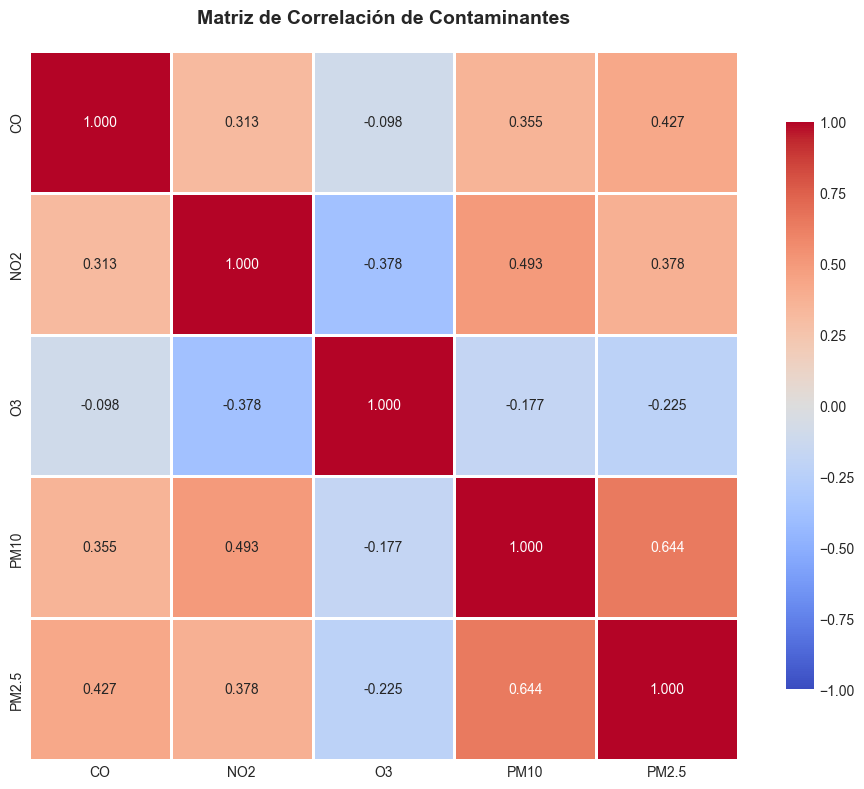


Matriz de Correlación:
             CO       NO2        O3      PM10     PM2.5
CO     1.000000  0.313131 -0.097669  0.355422  0.427446
NO2    0.313131  1.000000 -0.377608  0.492583  0.378428
O3    -0.097669 -0.377608  1.000000 -0.177137 -0.225297
PM10   0.355422  0.492583 -0.177137  1.000000  0.643516
PM2.5  0.427446  0.378428 -0.225297  0.643516  1.000000


In [8]:
# Calcular matriz de correlación
corr_matrix = df_pca[contaminantes].corr()

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Contaminantes', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nMatriz de Correlación:")
print(corr_matrix)

## Estandarización de Variables

Transformamos cada variable para que tenga media = 0 y desviación estándar = 1.

In [9]:
# Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear DataFrame con datos estandarizados
df_scaled = pd.DataFrame(X_scaled, columns=contaminantes, index=df_pca.index)

print("Datos originales:")
print(df_pca[contaminantes].describe())
print("\n" + "="*60 + "\n")
print("Datos estandarizados:")
print(df_scaled.describe())

# Verificar estandarización
print("\n" + "="*60)
print("Verificación de estandarización:")
print("="*60)
print(f"Medias (deben ser ≈ 0):")
print(df_scaled.mean())
print(f"\nDesviaciones estándar (deben ser ≈ 1):")
print(df_scaled.std())

Datos originales:
                 CO           NO2            O3          PM10         PM2.5
count  10016.000000  10016.000000  10016.000000  10016.000000  10016.000000
mean       1.372140     18.547164     12.488885     60.532166     20.866053
std        0.720926      8.754071      7.449791     36.495560     12.883449
min        0.090000      0.100000      1.000000      3.000000      1.000000
25%        0.827625     11.931250      7.000000     36.666667     11.280000
50%        1.175000     16.950000     10.750000     53.000000     18.202500
75%        1.790000     23.850000     16.250000     76.000000     27.762500
max        5.740000     61.200000     50.000000    625.166667    144.500000


Datos estandarizados:
                 CO           NO2            O3          PM10         PM2.5
count  1.001600e+04  1.001600e+04  1.001600e+04  1.001600e+04  1.001600e+04
mean  -1.759331e-16 -4.540209e-17 -1.418815e-17  2.270105e-17 -1.773519e-16
std    1.000050e+00  1.000050e+00  1.000050e+0

# PCA General (Dataset Completo)

Identificar patrones conjuntos dentro del sistema de contaminantes

## Aplicación del PCA

In [10]:
# Aplicar PCA con todos los componentes
pca_full = PCA()
X_pca = pca_full.fit_transform(X_scaled)

# Crear DataFrame con componentes principales
componentes_nombres = [f'PC{i+1}' for i in range(pca_full.n_components_)]
df_pca_scores = pd.DataFrame(X_pca, columns=componentes_nombres, index=df_pca.index)

print("=" * 60)
print("PCA - INFORMACIÓN GENERAL")
print("=" * 60)
print(f"\nNúmero de componentes principales: {pca_full.n_components_}")
print(f"Varianza explicada por cada componente:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
    
print(f"\nVarianza acumulada:")
for i, var in enumerate(np.cumsum(pca_full.explained_variance_ratio_)):
    print(f"  PC1-PC{i+1}: {var*100:.2f}%")

PCA - INFORMACIÓN GENERAL

Número de componentes principales: 5
Varianza explicada por cada componente:
  PC1: 49.12%
  PC2: 19.74%
  PC3: 13.53%
  PC4: 11.33%
  PC5: 6.27%

Varianza acumulada:
  PC1-PC1: 49.12%
  PC1-PC2: 68.86%
  PC1-PC3: 82.39%
  PC1-PC4: 93.73%
  PC1-PC5: 100.00%


## Scree Plot y Varianza Explicada

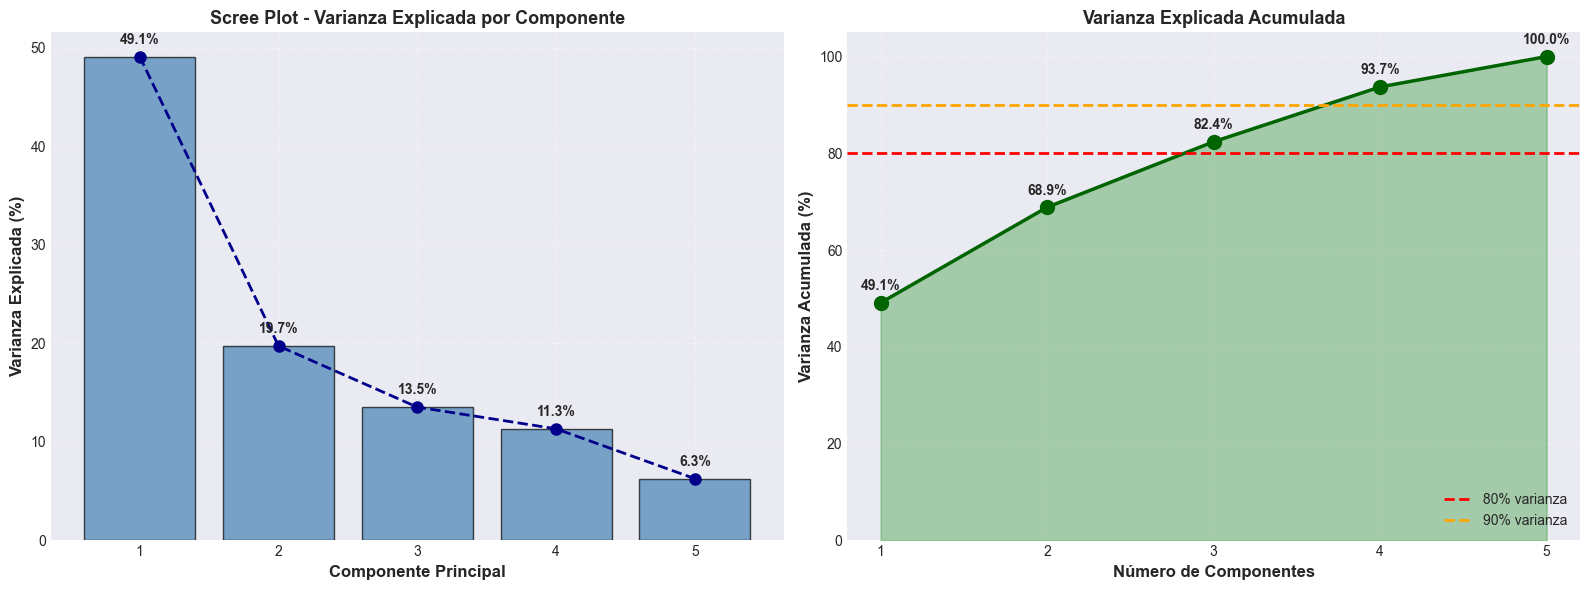


RESUMEN DE VARIANZA EXPLICADA
PC1: 49.12% | Acumulada: 49.12%
PC2: 19.74% | Acumulada: 68.86%
PC3: 13.53% | Acumulada: 82.39%
PC4: 11.33% | Acumulada: 93.73%
PC5: 6.27% | Acumulada: 100.00%


In [11]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Varianza explicada por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_ * 100,
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
             pca_full.explained_variance_ratio_ * 100,
             marker='o', linestyle='--', color='darkblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))

# Añadir valores en las barras
for i, v in enumerate(pca_full.explained_variance_ratio_ * 100):
    axes[0].text(i + 1, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Varianza acumulada
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 
             marker='o', linestyle='-', color='darkgreen', linewidth=2.5, markersize=10)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% varianza')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% varianza')
axes[1].fill_between(range(1, len(cumsum_var) + 1), cumsum_var, alpha=0.3, color='green')
axes[1].set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Varianza Explicada Acumulada', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xticks(range(1, len(cumsum_var) + 1))
axes[1].set_ylim([0, 105])

# Añadir valores en los puntos
for i, v in enumerate(cumsum_var):
    axes[1].text(i + 1, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen
print("\n" + "=" * 60)
print("RESUMEN DE VARIANZA EXPLICADA")
print("=" * 60)
for i in range(len(pca_full.explained_variance_ratio_)):
    print(f"PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% | Acumulada: {cumsum_var[i]:.2f}%")

## Cargas Factoriales (Loadings)

CARGAS FACTORIALES (LOADINGS)
            PC1       PC2       PC3       PC4       PC5
CO     0.398669  0.396340  0.813285  0.003155  0.150119
NO2    0.470859 -0.307060 -0.025815  0.763878 -0.315960
O3    -0.291676  0.809325 -0.219998  0.423565 -0.179196
PM10   0.519467  0.195955 -0.476038  0.024397  0.681578
PM2.5  0.514231  0.234997 -0.250779 -0.486290 -0.617231


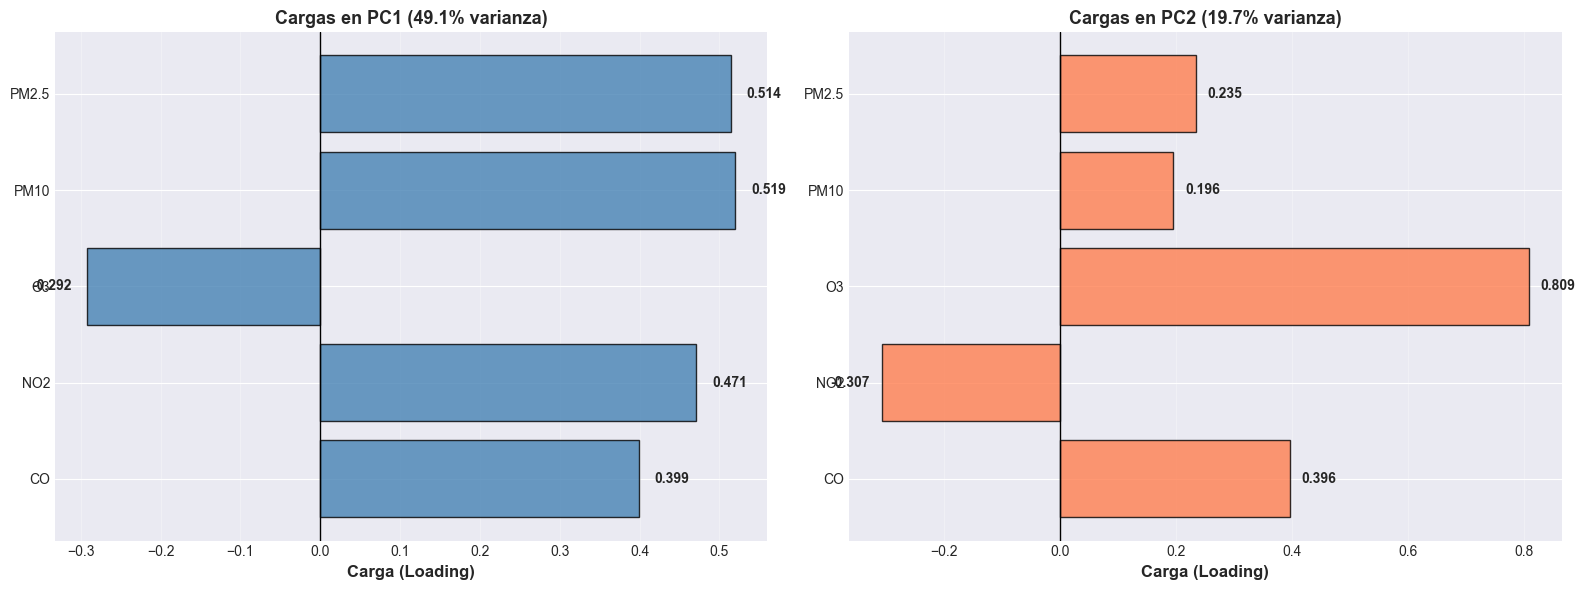

In [12]:
# Matriz de cargas (loadings)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=componentes_nombres,
    index=contaminantes
)

print("=" * 60)
print("CARGAS FACTORIALES (LOADINGS)")
print("=" * 60)
print(loadings)

# Visualizar loadings para PC1 y PC2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 Loadings
axes[0].barh(contaminantes, loadings['PC1'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Carga (Loading)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Cargas en PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings['PC1']):
    axes[0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                 va='center', ha='left' if v > 0 else 'right', fontweight='bold')

# PC2 Loadings
axes[1].barh(contaminantes, loadings['PC2'], color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Carga (Loading)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Cargas en PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings['PC2']):
    axes[1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                 va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretación de Componentes Principales

Basándonos en las cargas factoriales, interpretamos el significado físico/ambiental de cada componente.

In [13]:
# Identificar contaminantes principales por componente
print("=" * 60)
print("INTERPRETACIÓN DE COMPONENTES PRINCIPALES")
print("=" * 60)

for pc in ['PC1', 'PC2']:
    print(f"\n{pc} ({pca_full.explained_variance_ratio_[int(pc[2])-1]*100:.1f}% de varianza):")
    print("-" * 60)
    
    # Ordenar cargas por magnitud absoluta
    cargas_ordenadas = loadings[pc].abs().sort_values(ascending=False)
    
    print("Contaminantes más influyentes (por magnitud):")
    for cont in cargas_ordenadas.index:
        carga = loadings.loc[cont, pc]
        print(f"  {cont:6s}: {carga:+.4f}")
    
    # Interpretar significado
    print("\nInterpretación sugerida:")
    if pc == 'PC1':
        positivos = loadings[loadings['PC1'] > 0.3].index.tolist()
        negativos = loadings[loadings['PC1'] < -0.3].index.tolist()
        if positivos:
            print(f"  Asociado positivamente con: {', '.join(positivos)}")
        if negativos:
            print(f"  Asociado negativamente con: {', '.join(negativos)}")
    elif pc == 'PC2':
        positivos = loadings[loadings['PC2'] > 0.3].index.tolist()
        negativos = loadings[loadings['PC2'] < -0.3].index.tolist()
        if positivos:
            print(f"  Asociado positivamente con: {', '.join(positivos)}")
        if negativos:
            print(f"  Asociado negativamente con: {', '.join(negativos)}")

INTERPRETACIÓN DE COMPONENTES PRINCIPALES

PC1 (49.1% de varianza):
------------------------------------------------------------
Contaminantes más influyentes (por magnitud):
  PM10  : +0.5195
  PM2.5 : +0.5142
  NO2   : +0.4709
  CO    : +0.3987
  O3    : -0.2917

Interpretación sugerida:
  Asociado positivamente con: CO, NO2, PM10, PM2.5

PC2 (19.7% de varianza):
------------------------------------------------------------
Contaminantes más influyentes (por magnitud):
  O3    : +0.8093
  CO    : +0.3963
  NO2   : -0.3071
  PM2.5 : +0.2350
  PM10  : +0.1960

Interpretación sugerida:
  Asociado positivamente con: CO, O3
  Asociado negativamente con: NO2


## Biplot PC1–PC2

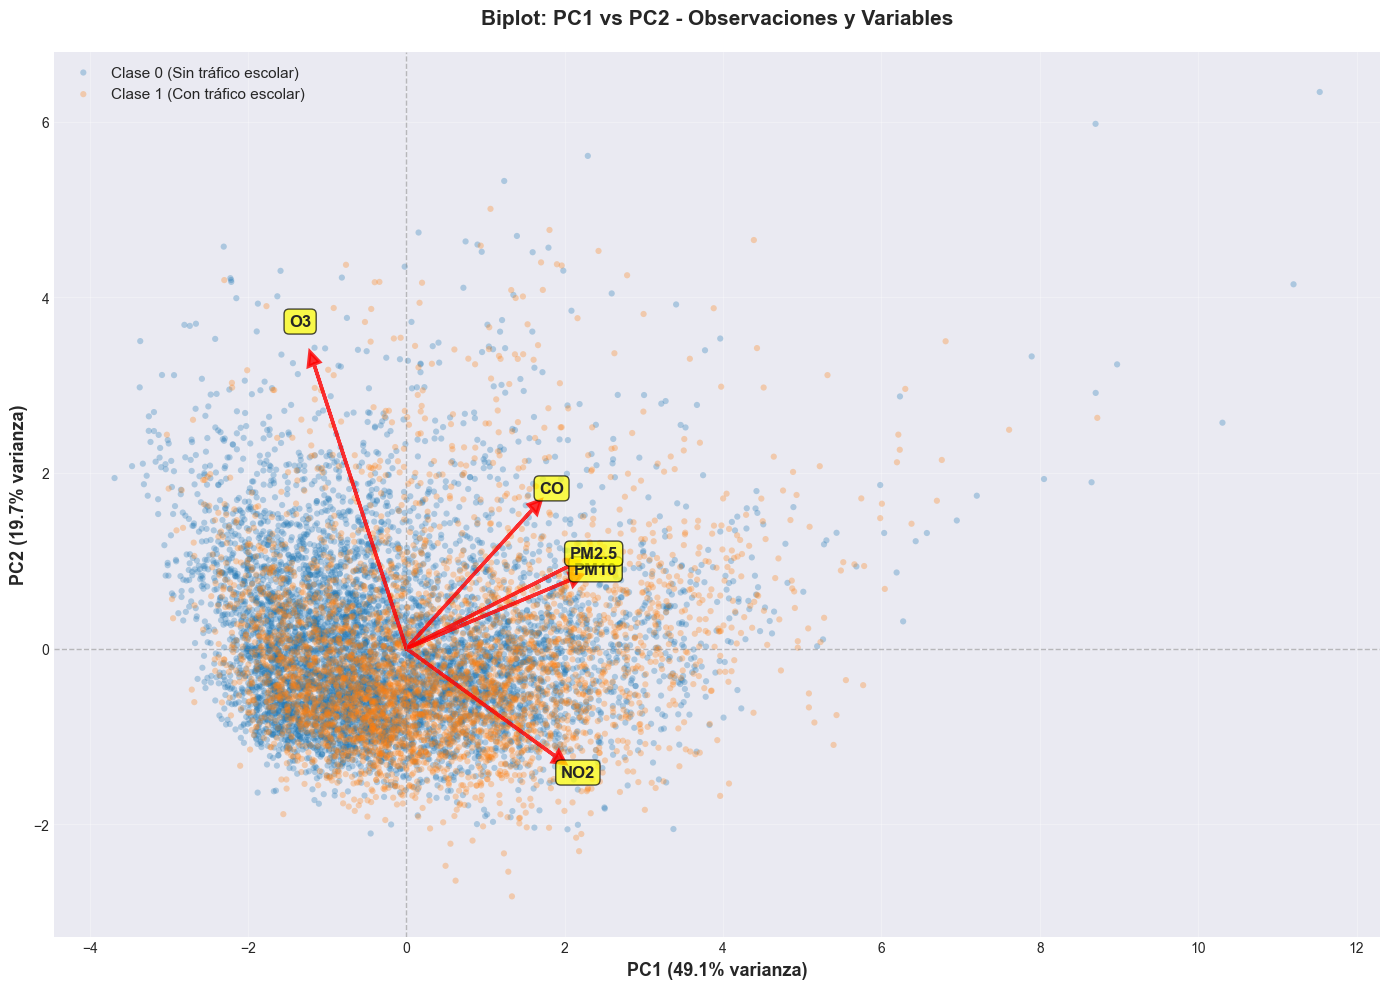

In [14]:
# Preparar datos para biplot
df_biplot = df_pca_scores[['PC1', 'PC2']].copy()
df_biplot['clase'] = df_pca['clase'].values

# Biplot
fig, ax = plt.subplots(figsize=(14, 10))

# Scatter plot de observaciones coloreadas por clase
clases = df_biplot['clase'].unique()
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels_clase = ['Clase 0 (Sin tráfico escolar)', 'Clase 1 (Con tráfico escolar)', 'Clase 2 (Transición)']

for i, clase in enumerate(sorted(clases)):
    mask = df_biplot['clase'] == clase
    ax.scatter(df_biplot.loc[mask, 'PC1'], 
               df_biplot.loc[mask, 'PC2'],
               alpha=0.3, s=20, c=colores[i], 
               label=labels_clase[i], edgecolors='none')

# Dibujar vectores de variables (loadings escalados)
scale = 4  # Factor de escala para visualizar mejor los vectores
for i, contaminante in enumerate(contaminantes):
    ax.arrow(0, 0, 
             loadings.loc[contaminante, 'PC1'] * scale, 
             loadings.loc[contaminante, 'PC2'] * scale,
             head_width=0.15, head_length=0.15, fc='red', ec='red', 
             linewidth=2.5, alpha=0.8)
    ax.text(loadings.loc[contaminante, 'PC1'] * scale * 1.15, 
            loadings.loc[contaminante, 'PC2'] * scale * 1.15,
            contaminante, fontsize=12, fontweight='bold', 
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Líneas de referencia
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Configuración
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', 
              fontsize=13, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', 
              fontsize=13, fontweight='bold')
ax.set_title('Biplot: PC1 vs PC2 - Observaciones y Variables', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Separación por Clase en el Espacio PCA

ESTADÍSTICAS DE COMPONENTES PRINCIPALES POR CLASE

Clase 0 (Sin tráfico escolar):
------------------------------------------------------------
PC1 - Media: -0.221, Std: 1.502
PC2 - Media: +0.059, Std: 0.973

Clase 1 (Con tráfico escolar):
------------------------------------------------------------
PC1 - Media: +0.378, Std: 1.604
PC2 - Media: -0.101, Std: 1.020


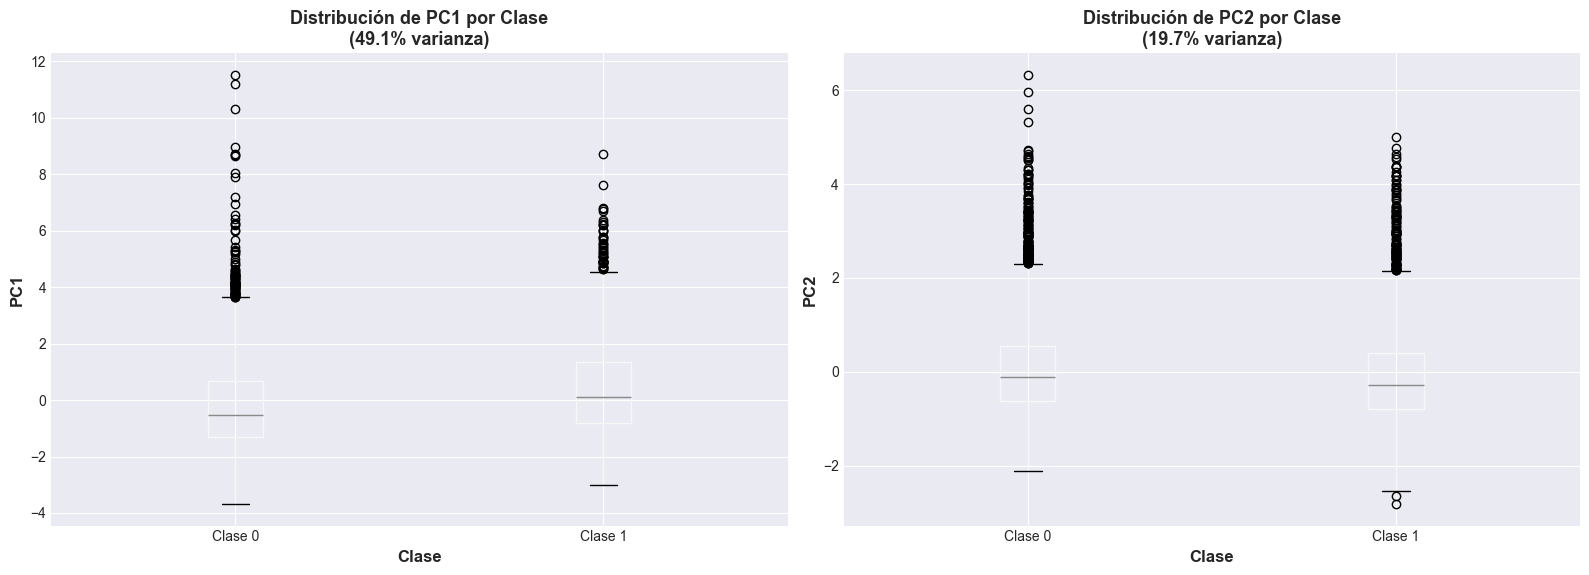

In [16]:
# Estadísticas de PC1 y PC2 por clase
print("=" * 60)
print("ESTADÍSTICAS DE COMPONENTES PRINCIPALES POR CLASE")
print("=" * 60)

# Determinar las clases presentes
clases_presentes = sorted(clases)
labels_clase_dict = {
    0: 'Clase 0 (Sin tráfico escolar)', 
    1: 'Clase 1 (Con tráfico escolar)', 
    2: 'Clase 2 (Transición)'
}

for clase in clases_presentes:
    print(f"\n{labels_clase_dict[int(clase)]}:")
    print("-" * 60)
    mask = df_biplot['clase'] == clase
    print(f"PC1 - Media: {df_biplot.loc[mask, 'PC1'].mean():+.3f}, "
          f"Std: {df_biplot.loc[mask, 'PC1'].std():.3f}")
    print(f"PC2 - Media: {df_biplot.loc[mask, 'PC2'].mean():+.3f}, "
          f"Std: {df_biplot.loc[mask, 'PC2'].std():.3f}")

# Boxplots por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 por clase
df_biplot.boxplot(column='PC1', by='clase', ax=axes[0])
axes[0].set_title(f'Distribución de PC1 por Clase\n({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PC1', fontsize=12, fontweight='bold')
# Establecer etiquetas dinámicamente según las clases presentes
axes[0].set_xticklabels([f'Clase {int(c)}' for c in clases_presentes])
axes[0].get_figure().suptitle('')

# PC2 por clase
df_biplot.boxplot(column='PC2', by='clase', ax=axes[1])
axes[1].set_title(f'Distribución de PC2 por Clase\n({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PC2', fontsize=12, fontweight='bold')
# Establecer etiquetas dinámicamente según las clases presentes
axes[1].set_xticklabels([f'Clase {int(c)}' for c in clases_presentes])
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# PCA por Temporada (Análisis Complementario)

**Propósito:** Detectar diferencias en la estructura multivariada según la temporada. Identificar si ciertos contaminantes dominan en:
- **Invierno:** Por ejemplo PM (acumulación, inversión térmica)
- **Verano:** Por ejemplo O₃ (fotoquímica)

## Preparación de Datos por Temporada

In [17]:
# Separar datos por temporada
df_verano = df_pca[df_pca['temporada'] == 'verano'].copy()
df_invierno = df_pca[df_pca['temporada'] == 'invierno'].copy()

print("=" * 60)
print("DATOS POR TEMPORADA")
print("=" * 60)
print(f"\nVerano: {len(df_verano)} observaciones ({len(df_verano)/len(df_pca)*100:.1f}%)")
print(f"Invierno: {len(df_invierno)} observaciones ({len(df_invierno)/len(df_pca)*100:.1f}%)")

# Extraer matrices y estandarizar
X_verano = df_verano[contaminantes].values
X_invierno = df_invierno[contaminantes].values

scaler_verano = StandardScaler()
scaler_invierno = StandardScaler()

X_verano_scaled = scaler_verano.fit_transform(X_verano)
X_invierno_scaled = scaler_invierno.fit_transform(X_invierno)

print("\n✓ Datos estandarizados por temporada")

DATOS POR TEMPORADA

Verano: 716 observaciones (7.1%)
Invierno: 1005 observaciones (10.0%)

✓ Datos estandarizados por temporada


## PCA para Verano

In [18]:
# PCA para verano
pca_verano = PCA()
X_pca_verano = pca_verano.fit_transform(X_verano_scaled)

# Loadings
loadings_verano = pd.DataFrame(
    pca_verano.components_.T,
    columns=componentes_nombres,
    index=contaminantes
)

print("=" * 60)
print("PCA VERANO - VARIANZA EXPLICADA")
print("=" * 60)
for i, var in enumerate(pca_verano.explained_variance_ratio_):
    cumvar = np.cumsum(pca_verano.explained_variance_ratio_)[i]
    print(f"PC{i+1}: {var*100:.2f}% | Acumulada: {cumvar*100:.2f}%")

print("\n" + "=" * 60)
print("CARGAS FACTORIALES - VERANO")
print("=" * 60)
print(loadings_verano[['PC1', 'PC2']])

PCA VERANO - VARIANZA EXPLICADA
PC1: 41.00% | Acumulada: 41.00%
PC2: 24.58% | Acumulada: 65.58%
PC3: 19.00% | Acumulada: 84.59%
PC4: 10.13% | Acumulada: 94.72%
PC5: 5.28% | Acumulada: 100.00%

CARGAS FACTORIALES - VERANO
            PC1       PC2
CO     0.101840  0.779414
NO2    0.521296  0.218921
O3    -0.119764  0.539409
PM10   0.635357 -0.003309
PM2.5  0.547592 -0.231547


## PCA para Invierno

In [19]:
# PCA para invierno
pca_invierno = PCA()
X_pca_invierno = pca_invierno.fit_transform(X_invierno_scaled)

# Loadings
loadings_invierno = pd.DataFrame(
    pca_invierno.components_.T,
    columns=componentes_nombres,
    index=contaminantes
)

print("=" * 60)
print("PCA INVIERNO - VARIANZA EXPLICADA")
print("=" * 60)
for i, var in enumerate(pca_invierno.explained_variance_ratio_):
    cumvar = np.cumsum(pca_invierno.explained_variance_ratio_)[i]
    print(f"PC{i+1}: {var*100:.2f}% | Acumulada: {cumvar*100:.2f}%")

print("\n" + "=" * 60)
print("CARGAS FACTORIALES - INVIERNO")
print("=" * 60)
print(loadings_invierno[['PC1', 'PC2']])

PCA INVIERNO - VARIANZA EXPLICADA
PC1: 49.67% | Acumulada: 49.67%
PC2: 19.80% | Acumulada: 69.48%
PC3: 15.85% | Acumulada: 85.33%
PC4: 8.96% | Acumulada: 94.29%
PC5: 5.71% | Acumulada: 100.00%

CARGAS FACTORIALES - INVIERNO
            PC1       PC2
CO     0.386026 -0.091397
NO2    0.454897 -0.317975
O3    -0.412827  0.639473
PM10   0.441986  0.610492
PM2.5  0.527517  0.330019


## Comparación Estacional de Componentes

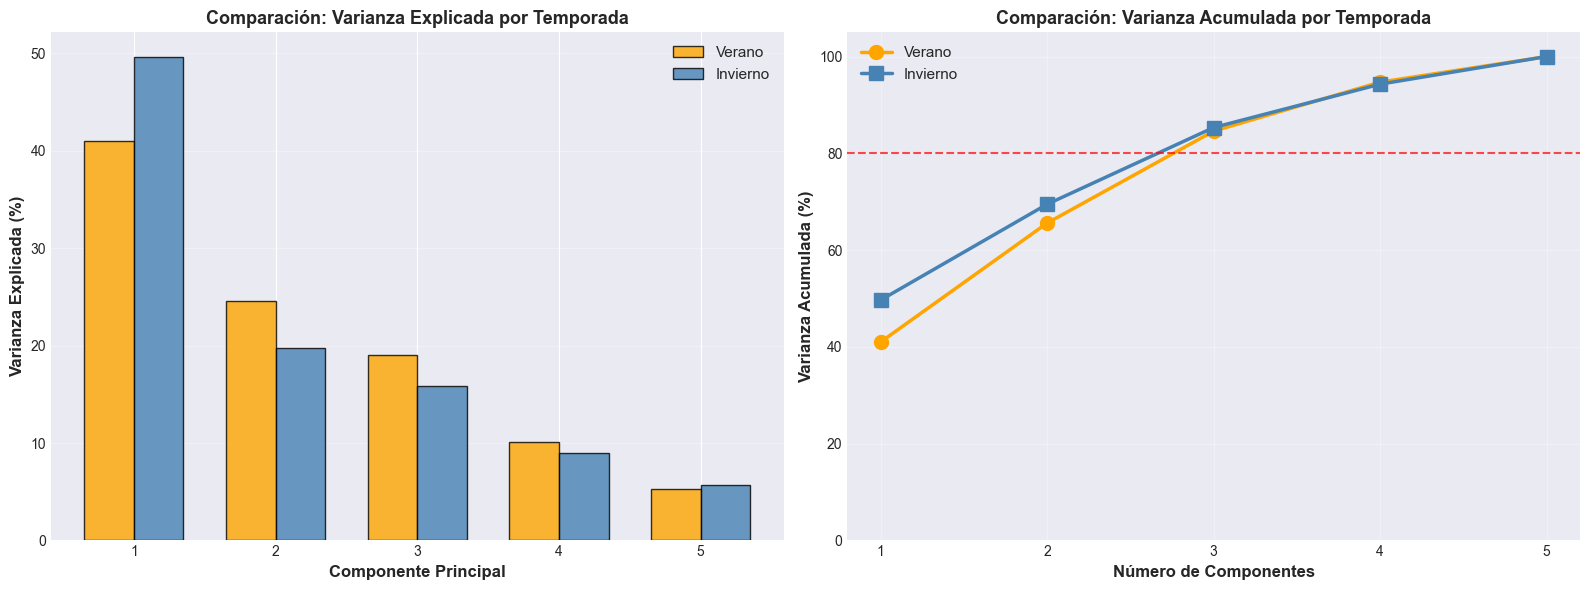

In [20]:
# Comparación de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot comparativo
x = np.arange(1, len(contaminantes) + 1)
width = 0.35

axes[0].bar(x - width/2, pca_verano.explained_variance_ratio_ * 100, 
            width, label='Verano', alpha=0.8, color='orange', edgecolor='black')
axes[0].bar(x + width/2, pca_invierno.explained_variance_ratio_ * 100, 
            width, label='Invierno', alpha=0.8, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación: Varianza Explicada por Temporada', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

# Varianza acumulada comparativa
axes[1].plot(x, np.cumsum(pca_verano.explained_variance_ratio_) * 100, 
             marker='o', linestyle='-', linewidth=2.5, markersize=10, 
             label='Verano', color='orange')
axes[1].plot(x, np.cumsum(pca_invierno.explained_variance_ratio_) * 100, 
             marker='s', linestyle='-', linewidth=2.5, markersize=10, 
             label='Invierno', color='steelblue')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Comparación: Varianza Acumulada por Temporada', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

### Comparación de Cargas Factoriales por Temporada

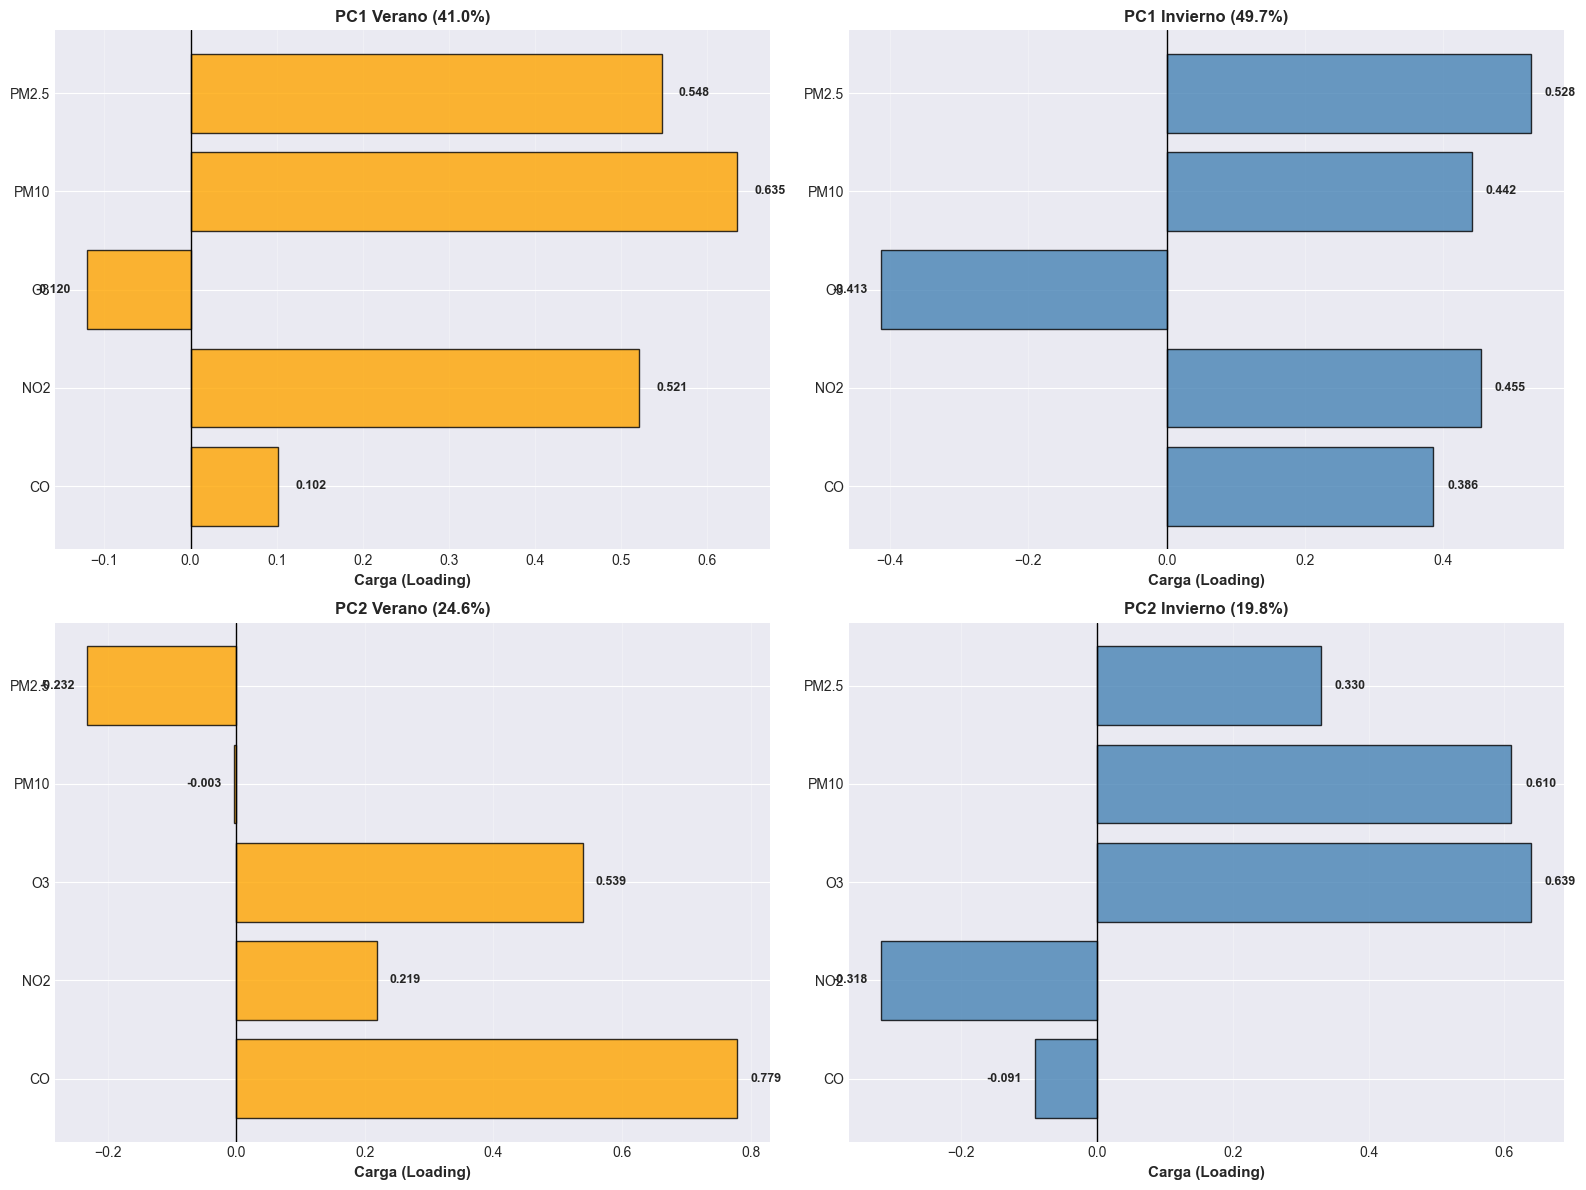

In [21]:
# Comparación de loadings para PC1 y PC2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PC1 - Verano
axes[0, 0].barh(contaminantes, loadings_verano['PC1'], color='orange', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 0].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'PC1 Verano ({pca_verano.explained_variance_ratio_[0]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_verano['PC1']):
    axes[0, 0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

# PC1 - Invierno
axes[0, 1].barh(contaminantes, loadings_invierno['PC1'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'PC1 Invierno ({pca_invierno.explained_variance_ratio_[0]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_invierno['PC1']):
    axes[0, 1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

# PC2 - Verano
axes[1, 0].barh(contaminantes, loadings_verano['PC2'], color='orange', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'PC2 Verano ({pca_verano.explained_variance_ratio_[1]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_verano['PC2']):
    axes[1, 0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

# PC2 - Invierno
axes[1, 1].barh(contaminantes, loadings_invierno['PC2'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Carga (Loading)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(f'PC2 Invierno ({pca_invierno.explained_variance_ratio_[1]*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')
for i, v in enumerate(loadings_invierno['PC2']):
    axes[1, 1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Análisis de Diferencias Estacionales

In [22]:
# Tabla comparativa de loadings
comparison_df = pd.DataFrame({
    'PC1_Verano': loadings_verano['PC1'],
    'PC1_Invierno': loadings_invierno['PC1'],
    'Dif_PC1': loadings_verano['PC1'] - loadings_invierno['PC1'],
    'PC2_Verano': loadings_verano['PC2'],
    'PC2_Invierno': loadings_invierno['PC2'],
    'Dif_PC2': loadings_verano['PC2'] - loadings_invierno['PC2']
})

print("=" * 80)
print("COMPARACIÓN DE CARGAS FACTORIALES: VERANO vs INVIERNO")
print("=" * 80)
print(comparison_df)

print("\n" + "=" * 80)
print("DIFERENCIAS MÁS NOTABLES")
print("=" * 80)

# PC1
print("\nPC1 - Mayores diferencias absolutas:")
dif_pc1 = comparison_df['Dif_PC1'].abs().sort_values(ascending=False)
for cont in dif_pc1.index[:3]:
    diff = comparison_df.loc[cont, 'Dif_PC1']
    v_ver = comparison_df.loc[cont, 'PC1_Verano']
    v_inv = comparison_df.loc[cont, 'PC1_Invierno']
    print(f"  {cont}: Verano={v_ver:+.3f}, Invierno={v_inv:+.3f}, Diferencia={diff:+.3f}")

# PC2
print("\nPC2 - Mayores diferencias absolutas:")
dif_pc2 = comparison_df['Dif_PC2'].abs().sort_values(ascending=False)
for cont in dif_pc2.index[:3]:
    diff = comparison_df.loc[cont, 'Dif_PC2']
    v_ver = comparison_df.loc[cont, 'PC2_Verano']
    v_inv = comparison_df.loc[cont, 'PC2_Invierno']
    print(f"  {cont}: Verano={v_ver:+.3f}, Invierno={v_inv:+.3f}, Diferencia={diff:+.3f}")

COMPARACIÓN DE CARGAS FACTORIALES: VERANO vs INVIERNO
       PC1_Verano  PC1_Invierno   Dif_PC1  PC2_Verano  PC2_Invierno   Dif_PC2
CO       0.101840      0.386026 -0.284186    0.779414     -0.091397  0.870811
NO2      0.521296      0.454897  0.066398    0.218921     -0.317975  0.536896
O3      -0.119764     -0.412827  0.293063    0.539409      0.639473 -0.100063
PM10     0.635357      0.441986  0.193371   -0.003309      0.610492 -0.613801
PM2.5    0.547592      0.527517  0.020075   -0.231547      0.330019 -0.561566

DIFERENCIAS MÁS NOTABLES

PC1 - Mayores diferencias absolutas:
  O3: Verano=-0.120, Invierno=-0.413, Diferencia=+0.293
  CO: Verano=+0.102, Invierno=+0.386, Diferencia=-0.284
  PM10: Verano=+0.635, Invierno=+0.442, Diferencia=+0.193

PC2 - Mayores diferencias absolutas:
  CO: Verano=+0.779, Invierno=-0.091, Diferencia=+0.871
  PM10: Verano=-0.003, Invierno=+0.610, Diferencia=-0.614
  PM2.5: Verano=-0.232, Invierno=+0.330, Diferencia=-0.562


## Biplots por Temporada

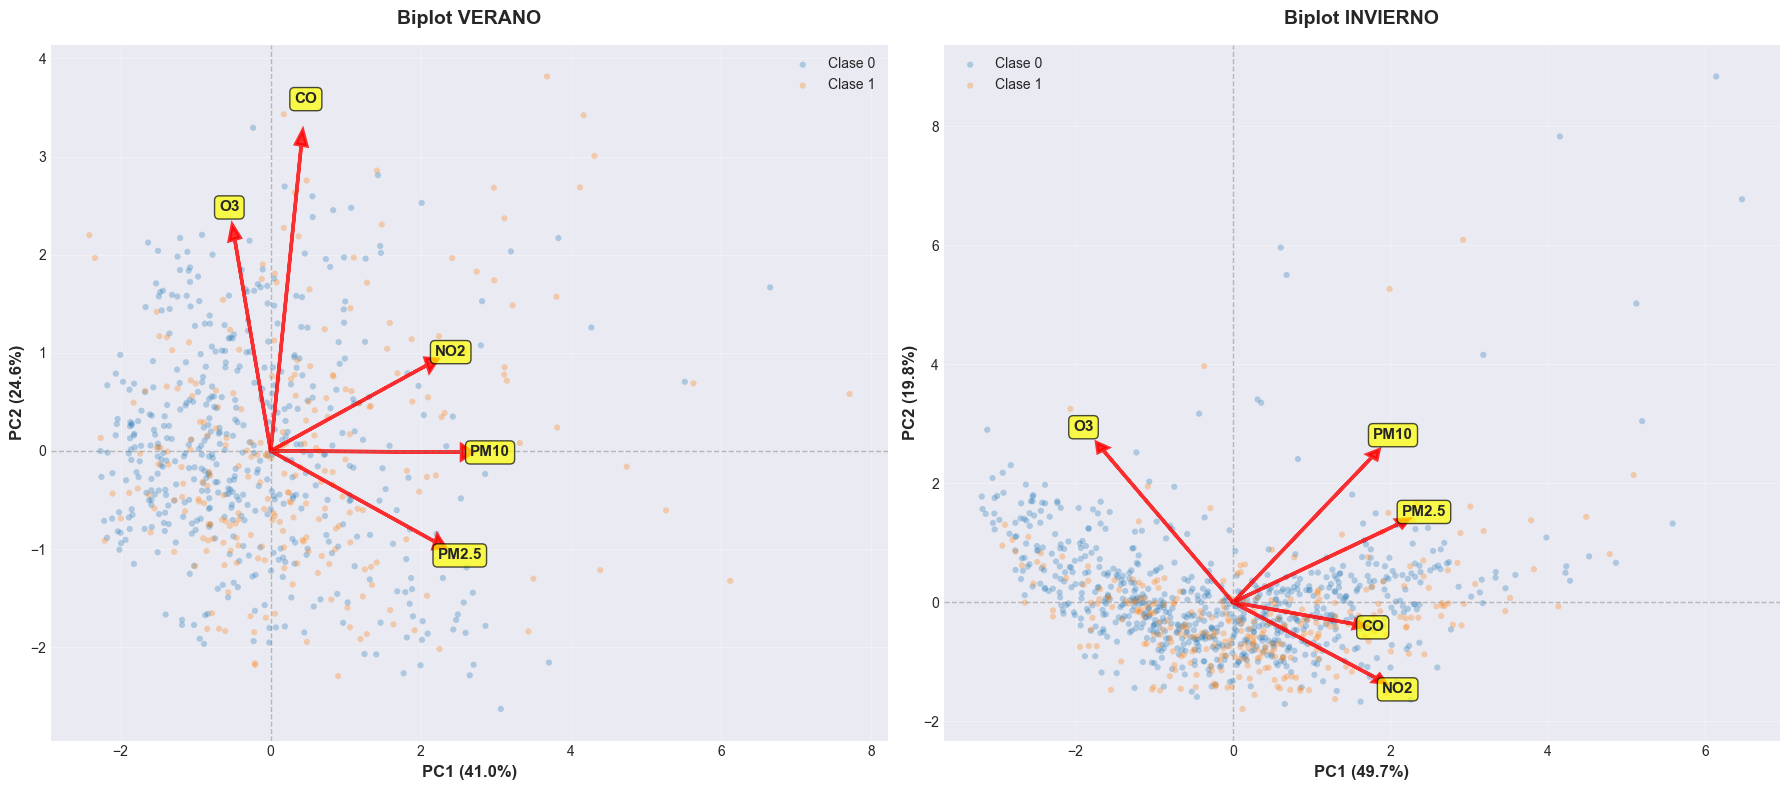

In [23]:
# Preparar datos para biplots
df_biplot_verano = pd.DataFrame(X_pca_verano[:, :2], columns=['PC1', 'PC2'])
df_biplot_verano['clase'] = df_verano['clase'].values

df_biplot_invierno = pd.DataFrame(X_pca_invierno[:, :2], columns=['PC1', 'PC2'])
df_biplot_invierno['clase'] = df_invierno['clase'].values

# Crear biplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Configuración común
scale = 4
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels_clase = ['Clase 0', 'Clase 1', 'Clase 2']

# Biplot VERANO
for i, clase in enumerate(sorted(clases)):
    mask = df_biplot_verano['clase'] == clase
    axes[0].scatter(df_biplot_verano.loc[mask, 'PC1'], 
                   df_biplot_verano.loc[mask, 'PC2'],
                   alpha=0.3, s=20, c=colores[i], 
                   label=labels_clase[i], edgecolors='none')

# Vectores de variables - Verano
for i, contaminante in enumerate(contaminantes):
    axes[0].arrow(0, 0, 
                 loadings_verano.loc[contaminante, 'PC1'] * scale, 
                 loadings_verano.loc[contaminante, 'PC2'] * scale,
                 head_width=0.15, head_length=0.15, fc='red', ec='red', 
                 linewidth=2.5, alpha=0.8)
    axes[0].text(loadings_verano.loc[contaminante, 'PC1'] * scale * 1.15, 
                loadings_verano.loc[contaminante, 'PC2'] * scale * 1.15,
                contaminante, fontsize=11, fontweight='bold', 
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel(f'PC1 ({pca_verano.explained_variance_ratio_[0]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca_verano.explained_variance_ratio_[1]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[0].set_title('Biplot VERANO', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(loc='best', fontsize=10, framealpha=0.9)
axes[0].grid(alpha=0.3)

# Biplot INVIERNO
for i, clase in enumerate(sorted(clases)):
    mask = df_biplot_invierno['clase'] == clase
    axes[1].scatter(df_biplot_invierno.loc[mask, 'PC1'], 
                   df_biplot_invierno.loc[mask, 'PC2'],
                   alpha=0.3, s=20, c=colores[i], 
                   label=labels_clase[i], edgecolors='none')

# Vectores de variables - Invierno
for i, contaminante in enumerate(contaminantes):
    axes[1].arrow(0, 0, 
                 loadings_invierno.loc[contaminante, 'PC1'] * scale, 
                 loadings_invierno.loc[contaminante, 'PC2'] * scale,
                 head_width=0.15, head_length=0.15, fc='red', ec='red', 
                 linewidth=2.5, alpha=0.8)
    axes[1].text(loadings_invierno.loc[contaminante, 'PC1'] * scale * 1.15, 
                loadings_invierno.loc[contaminante, 'PC2'] * scale * 1.15,
                contaminante, fontsize=11, fontweight='bold', 
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel(f'PC1 ({pca_invierno.explained_variance_ratio_[0]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca_invierno.explained_variance_ratio_[1]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
axes[1].set_title('Biplot INVIERNO', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc='best', fontsize=10, framealpha=0.9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen y Conclusiones del Análisis PCA

In [25]:
# Resumen cuantitativo final
print("=" * 80)
print("RESUMEN EJECUTIVO DEL ANÁLISIS PCA")
print("=" * 80)

print("\n1. VALIDACIÓN DE SUPUESTOS")
print("-" * 80)
print(f"   KMO Global: {kmo_model:.4f} - {interpretacion}")
print(f"   Prueba de Bartlett: Chi² = {chi_square_value:.2f}, p-valor = {p_value:.2e}")
print("   Conclusión: PCA es apropiado para este dataset")

print("\n2. PCA GENERAL (Dataset Completo)")
print("-" * 80)
print(f"   Varianza explicada por PC1: {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"   Varianza explicada por PC2: {pca_full.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Varianza acumulada PC1+PC2: {(pca_full.explained_variance_ratio_[0] + pca_full.explained_variance_ratio_[1])*100:.2f}%")
print(f"   Total de observaciones: {len(df_pca):,}")

print("\n3. ANÁLISIS POR TEMPORADA")
print("-" * 80)
print(f"   Verano:")
print(f"      - Observaciones: {len(df_verano):,}")
print(f"      - PC1 varianza: {pca_verano.explained_variance_ratio_[0]*100:.2f}%")
print(f"      - PC2 varianza: {pca_verano.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Invierno:")
print(f"      - Observaciones: {len(df_invierno):,}")
print(f"      - PC1 varianza: {pca_invierno.explained_variance_ratio_[0]*100:.2f}%")
print(f"      - PC2 varianza: {pca_invierno.explained_variance_ratio_[1]*100:.2f}%")

print("\n4. CONTAMINANTES CLAVE")
print("-" * 80)
print("   PC1 (Mayor contribución):")
for cont in loadings['PC1'].abs().nlargest(3).index:
    print(f"      - {cont}: {loadings.loc[cont, 'PC1']:+.4f}")
print("   PC2 (Mayor contribución):")
for cont in loadings['PC2'].abs().nlargest(3).index:
    print(f"      - {cont}: {loadings.loc[cont, 'PC2']:+.4f}")

RESUMEN EJECUTIVO DEL ANÁLISIS PCA

1. VALIDACIÓN DE SUPUESTOS
--------------------------------------------------------------------------------
   KMO Global: 0.6905 - Mediocre - PCA puede aplicarse con precaución
   Prueba de Bartlett: Chi² = 12337.21, p-valor = 0.00e+00
   Conclusión: PCA es apropiado para este dataset

2. PCA GENERAL (Dataset Completo)
--------------------------------------------------------------------------------
   Varianza explicada por PC1: 49.12%
   Varianza explicada por PC2: 19.74%
   Varianza acumulada PC1+PC2: 68.86%
   Total de observaciones: 10,016

3. ANÁLISIS POR TEMPORADA
--------------------------------------------------------------------------------
   Verano:
      - Observaciones: 716
      - PC1 varianza: 41.00%
      - PC2 varianza: 24.58%
   Invierno:
      - Observaciones: 1,005
      - PC1 varianza: 49.67%
      - PC2 varianza: 19.80%

4. CONTAMINANTES CLAVE
--------------------------------------------------------------------------------
   P